In [44]:
import pandas as pd
encoded_data = pd.read_csv("../data/proccessed/encoded-data.csv")
features_for_clustering = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Total_Services']
clustering_data = encoded_data[features_for_clustering]

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_data)
scaled_df = pd.DataFrame(scaled_data, columns=features_for_clustering)


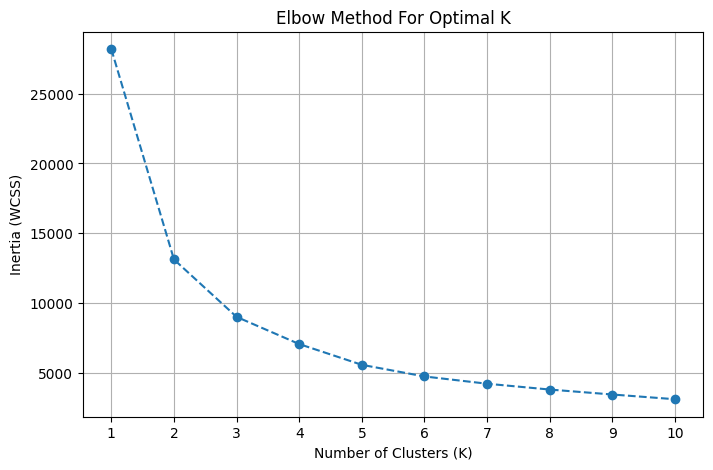

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [47]:

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_df)
encoded_data['Customer_Segment'] = cluster_labels
distances = kmeans.transform(scaled_df)
for i in range(optimal_k):
    encoded_data[f'Dist_to_Cluster_{i}'] = distances[:, i]
cluster_summary = encoded_data.groupby('Customer_Segment')[features_for_clustering].mean()
print(cluster_summary)


                     tenure  MonthlyCharges  TotalCharges  Total_Services
Customer_Segment                                                         
0                 59.789606       91.259157   5447.205197        4.095358
1                  8.779724       37.810058    291.153503        0.315817
2                 18.349199       79.775011   1437.972082        2.342792
3                 53.279234       29.937903   1581.961492        0.526210


In [48]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN


kmeans_silhouette = silhouette_score(scaled_df, cluster_labels) 
print(f"K-Means (K=4) Silhouette Score: {kmeans_silhouette:.4f}")

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df)

unique_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN found {unique_clusters} clusters.")

if unique_clusters > 1:
    dbscan_silhouette = silhouette_score(scaled_df, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")
else:
    print("Fail")


K-Means (K=4) Silhouette Score: 0.3953
DBSCAN found 11 clusters.
DBSCAN Silhouette Score: 0.0108


In [49]:
encoded_data.to_csv("../data/proccessed/finish-unsupervised.csv", index=False)